In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import joblib
import os
import uuid
import xgboost as xgb

In [3]:
df=pd.read_csv("E:\pcos\pcos_synthetic_50000.csv")

In [4]:

df.head()

,Hormonal_Imbalance,Hyperandrogenism,Hirsutism,Testosterone_ng_per_dL,Menstrual_Cycle,LH_FSH_Ratio,Conception_Difficulty,Family_History_PCOS,Family_History_Menstrual,Insulin_Resistance,...,Age,Weight_kg,Height_cm,Diet_Type,Veg_or_NonVeg,Exercise_hrs_per_week,Sleep_hrs_per_night,Stress_score_0_10,Smoking_Status,PCOS
0,0,0,0,52.0,Regular,1.05,0,0,0,0,...,32,69.7,167.2,Vegetarian,Vegetarian,11.1,7.9,4.8,Never,0
1,1,0,0,22.7,Irregular,1.57,0,0,0,0,...,28,55.9,151.9,Mixed,Non-vegetarian,0.3,6.9,10.0,Never,1
2,1,0,0,38.3,Irregular,1.72,0,0,0,0,...,33,77.4,164.0,Non-vegetarian,Non-vegetarian,1.3,6.8,4.1,Never,1
3,1,0,0,36.7,Irregular,1.29,0,0,0,0,...,39,76.1,155.7,Non-vegetarian,Non-vegetarian,1.0,4.9,5.6,Never,1
4,1,1,1,45.1,Irregular,1.77,0,0,0,0,...,27,68.6,157.7,Non-vegetarian,Non-vegetarian,0.8,7.4,3.9,Never,1


In [5]:
df['PCOS'].value_counts()
print(df['PCOS'].value_counts(normalize=True))
df.describe()

PCOS
0    0.50136
1    0.49864
Name: proportion, dtype: float64


,Hormonal_Imbalance,Hyperandrogenism,Hirsutism,Testosterone_ng_per_dL,LH_FSH_Ratio,Conception_Difficulty,Family_History_PCOS,Family_History_Menstrual,Insulin_Resistance,Diabetes,Cardiovascular_Disease,Childhood_Trauma,Age,Weight_kg,Height_cm,Exercise_hrs_per_week,Sleep_hrs_per_night,Stress_score_0_10,PCOS
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.420820,0.255420,0.248400,38.161970,1.378778,0.105560,0.101840,0.120360,0.033080,0.049100,0.012140,0.121900,29.053560,63.023120,160.029262,2.483624,6.997206,4.519420,0.498640
std,0.493696,0.436101,0.432089,11.263277,0.574555,0.307277,0.302441,0.325385,0.178847,0.216079,0.109512,0.327174,6.367598,12.599281,6.983584,2.452227,1.097171,2.148672,0.500003
min,0.000000,0.000000,0.000000,8.000000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,31.400000,140.000000,0.000000,4.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,30.400000,0.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,54.000000,155.300000,0.700000,6.200000,3.000000,0.000000
50%,0.000000,0.000000,0.000000,38.000000,1.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,62.400000,160.000000,1.700000,7.000000,4.500000,0.000000
75%,1.000000,1.000000,0.000000,45.700000,1.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.000000,71.300000,164.700000,3.500000,7.700000,6.000000,1.000000
max,1.000000,1.000000,1.000000,83.800000,3.630000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.000000,124.000000,190.000000,15.000000,10.000000,10.000000,1.000000


In [6]:
categorical_features=['Menstrual_Cycle', 'Diet_Type']
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for Menstrual_Cycle:
Menstrual_Cycle
Regular           33687
Irregular          9216
Oligomenorrhea     6029
Amenorrhea         1068
Name: count, dtype: int64

Value counts for Diet_Type:
Diet_Type
Non-vegetarian    27472
Vegetarian        12577
Mixed              7420
Vegan              2531
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())


Hormonal_Imbalance             0
Hyperandrogenism               0
Hirsutism                      0
Testosterone_ng_per_dL         0
Menstrual_Cycle                0
LH_FSH_Ratio                   0
Conception_Difficulty          0
Family_History_PCOS            0
Family_History_Menstrual       0
Insulin_Resistance             0
Diabetes                       0
Cardiovascular_Disease         0
Mental_Health               1408
Childhood_Trauma               0
Age                            0
Weight_kg                      0
Height_cm                      0
Diet_Type                      0
Veg_or_NonVeg                  0
Exercise_hrs_per_week          0
Sleep_hrs_per_night            0
Stress_score_0_10              0
Smoking_Status                 0
PCOS                           0
dtype: int64


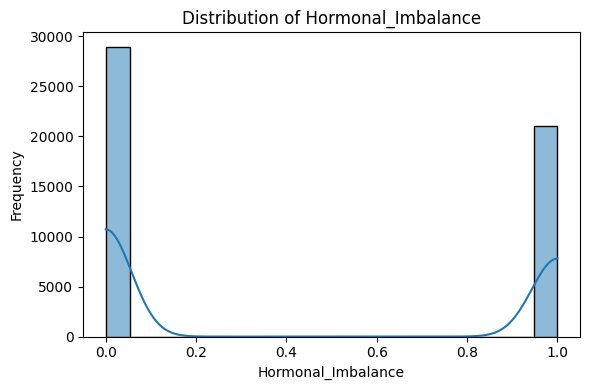

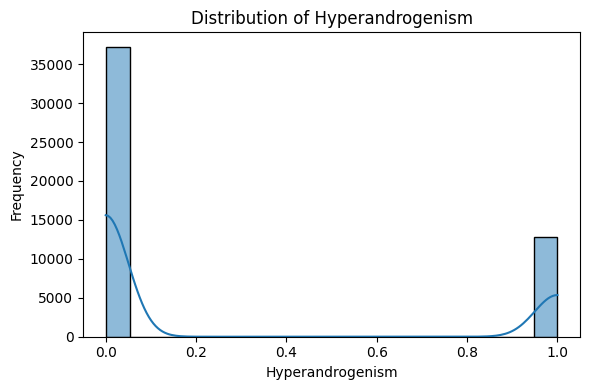

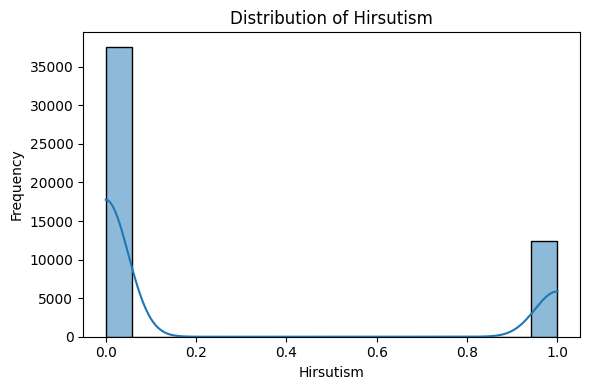

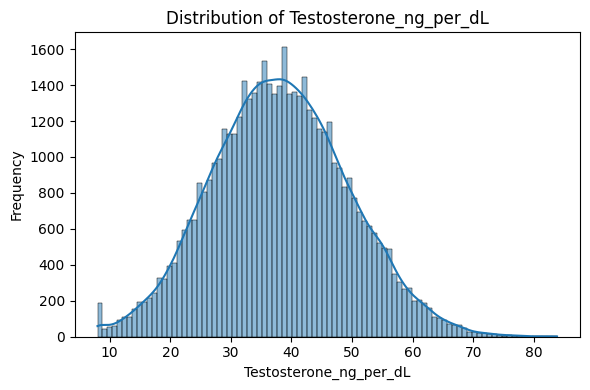

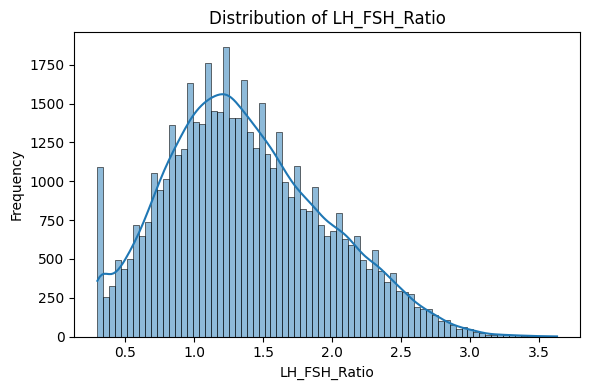

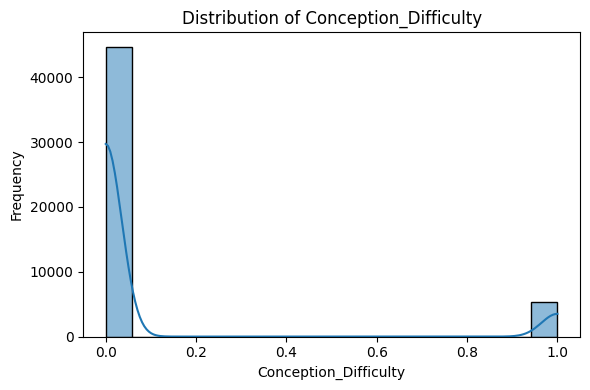

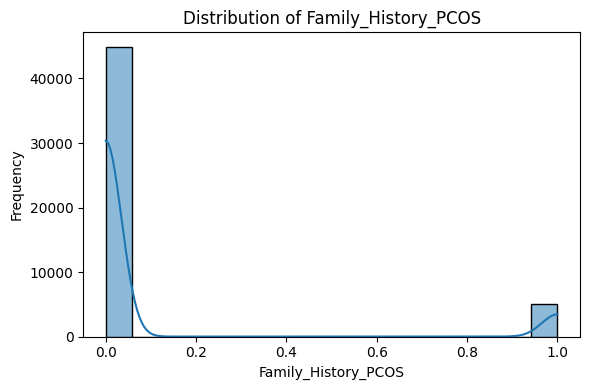

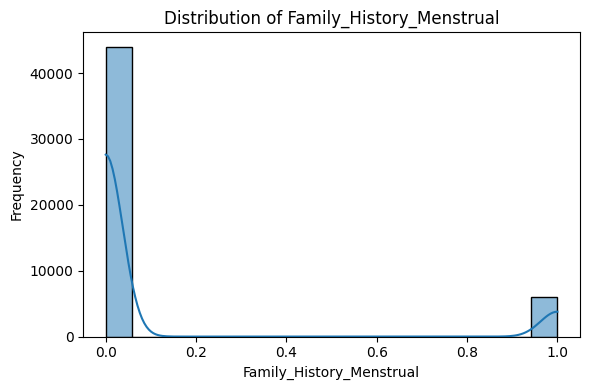

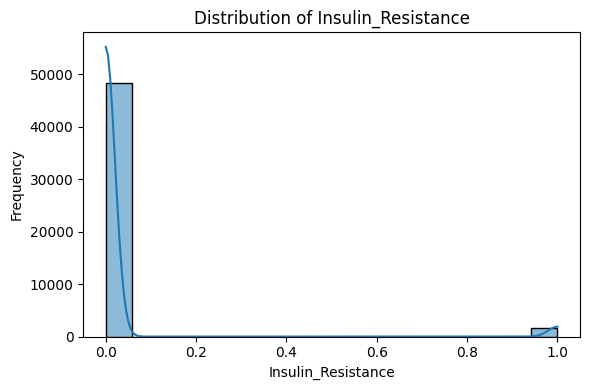

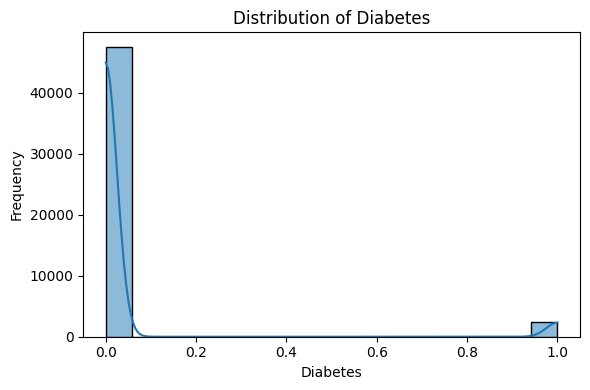

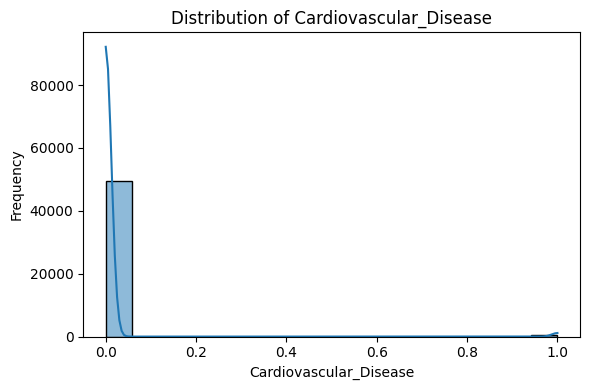

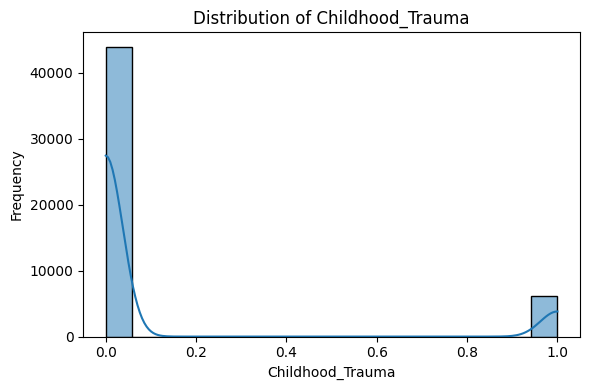

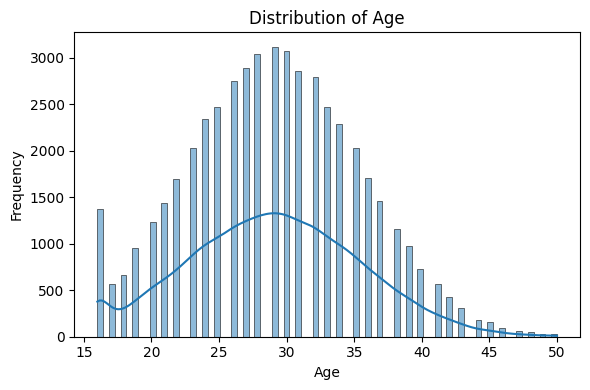

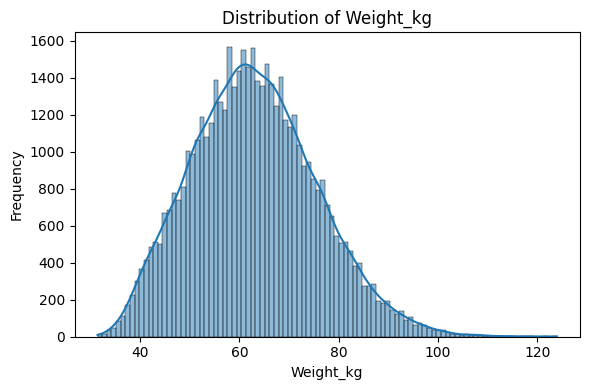

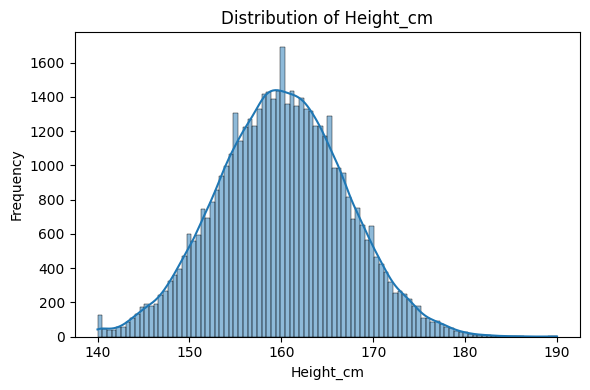

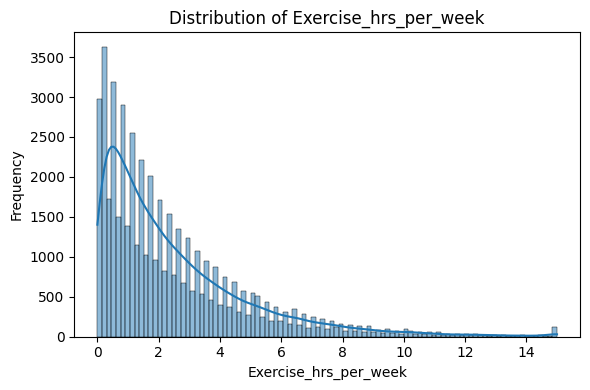

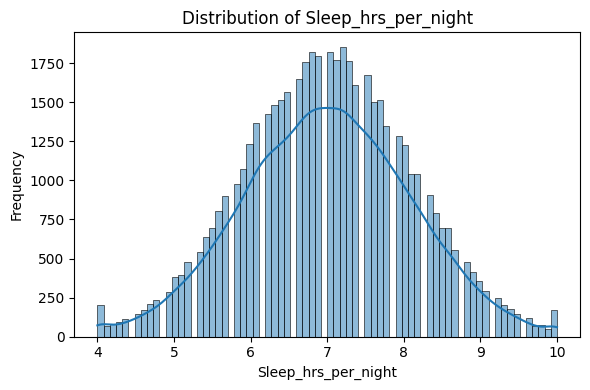

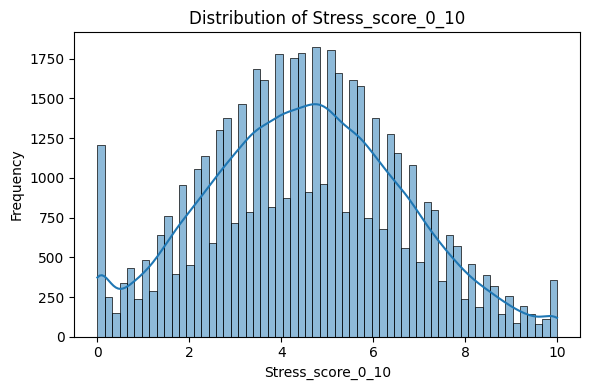

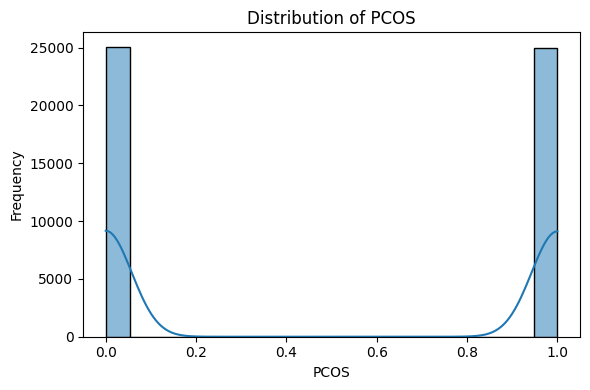

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))  # Better size
    
    # Drop NaN values
    data = df[col].dropna()
    
    sns.histplot(data, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


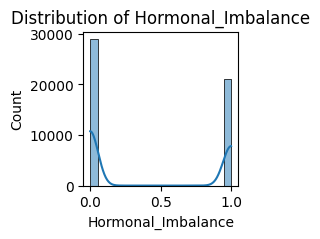

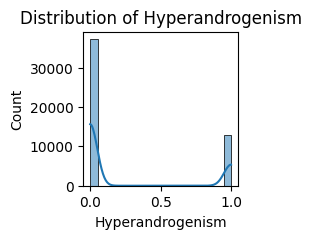

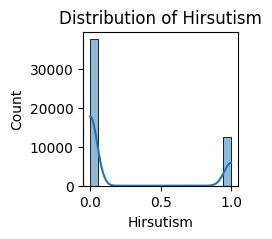

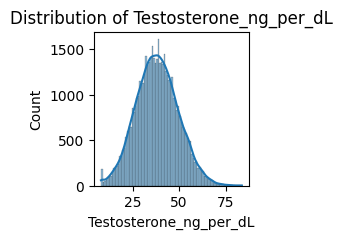

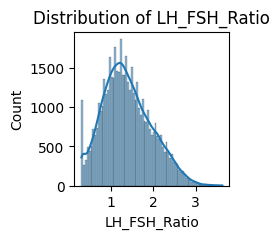

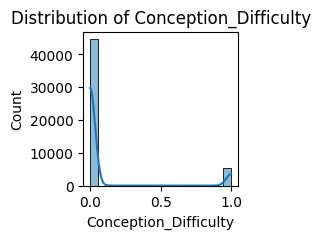

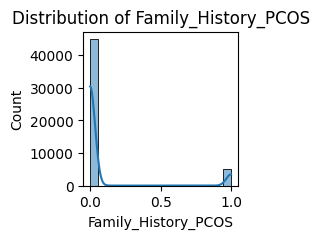

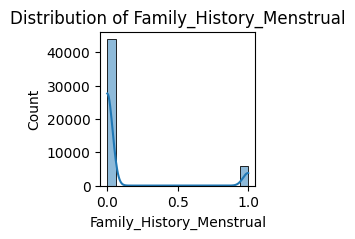

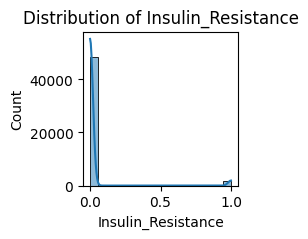

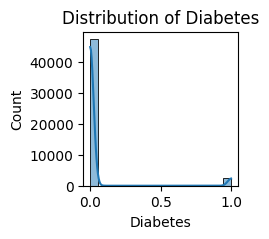

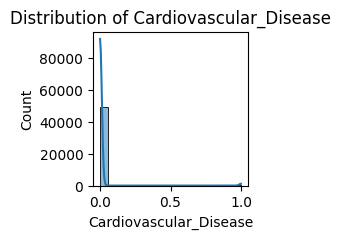

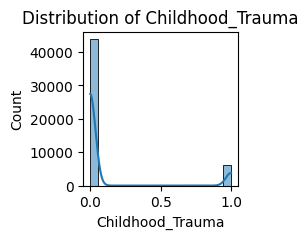

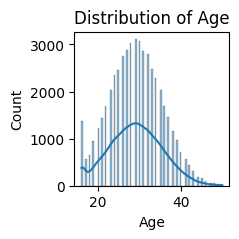

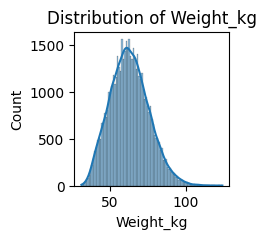

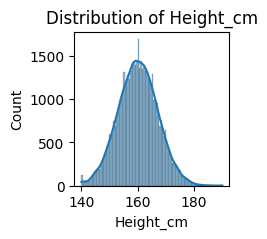

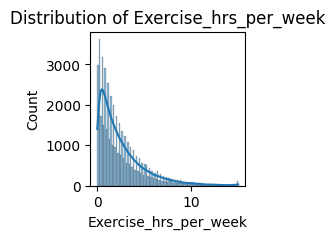

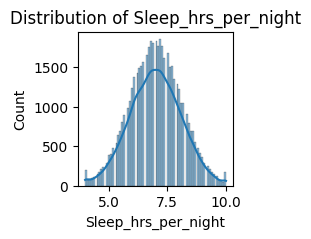

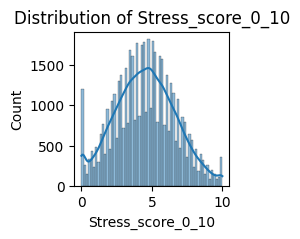

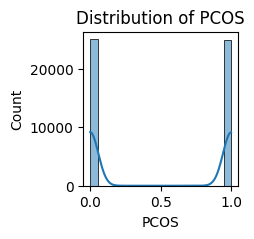

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns 
numercial_cols=df.select_dtypes(include=['float64','int64']).columns 
for col in numercial_cols: 
    plt.figure(figsize=(2,2))
    sns.histplot(df[col], kde=True) 
    plt.title(f'Distribution of {col}') 
    plt.show()

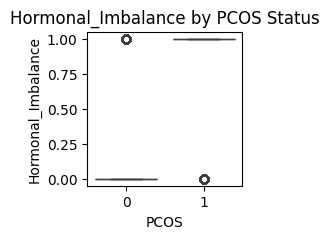

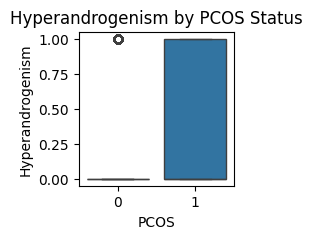

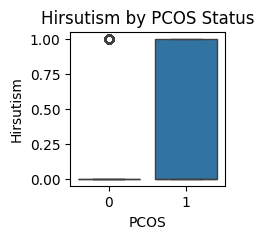

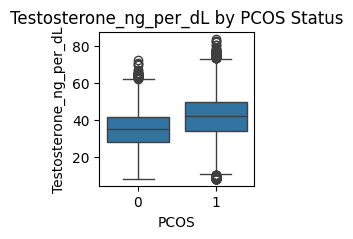

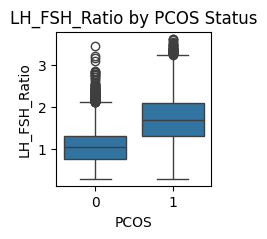

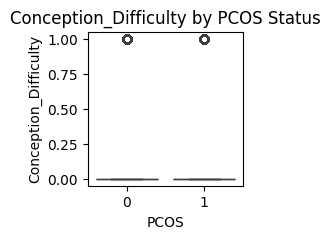

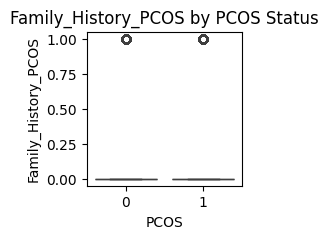

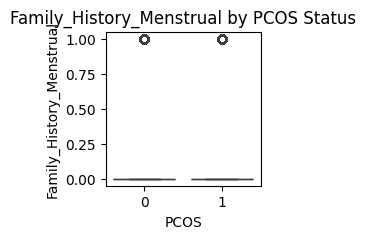

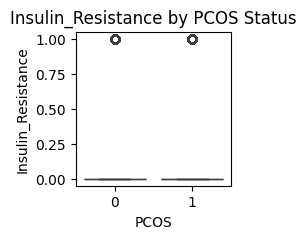

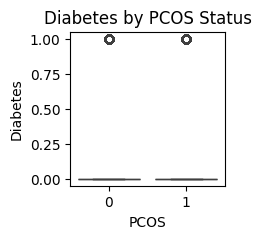

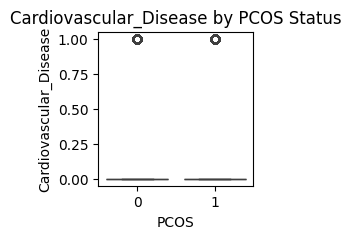

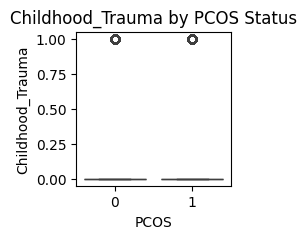

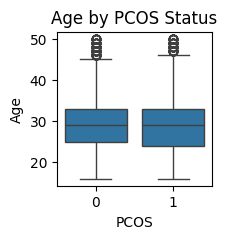

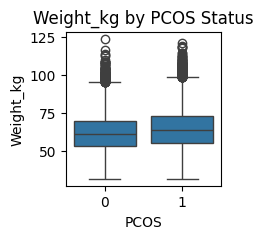

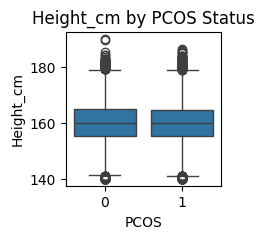

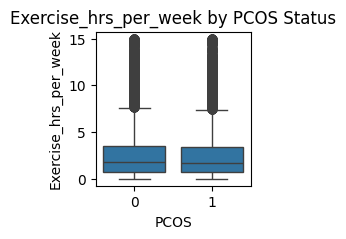

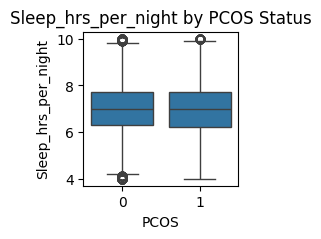

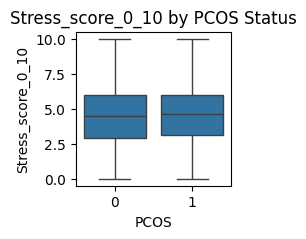

In [10]:
for col in numercial_cols:
    if col != 'PCOS':
        plt.figure(figsize=(2,2))
        sns.boxplot(x='PCOS', y=col, data=df)
        plt.title(f'{col} by PCOS Status')
        plt.show()


In [11]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in categorical_cols:
    print(pd.crosstab(df[col], df['PCOS']))

PCOS                 0     1
Menstrual_Cycle             
Amenorrhea          54  1014
Irregular          566  8650
Oligomenorrhea     364  5665
Regular          24084  9603
PCOS               0      1
Mental_Health              
Mild            9873   9703
Moderate       12556  12532
Severe          1905   2023
PCOS                0      1
Diet_Type                   
Mixed            3719   3701
Non-vegetarian  13780  13692
Vegan            1268   1263
Vegetarian       6301   6276
PCOS                0      1
Veg_or_NonVeg               
Non-vegetarian  18767  18656
Vegetarian       6301   6276
PCOS                0      1
Smoking_Status              
Current          2581   2502
Former           2963   2957
Never           19524  19473


In [12]:
mode_value = df['Mental_Health'].mode()[0]
df['Mental_Health'].fillna(mode_value, inplace=True)

Outlier Handling Summary (IQR method):
  - Hirsutism: 12420 outliers (24.84%)
  - Testosterone_ng_per_dL: 183 outliers (0.37%)
  - LH_FSH_Ratio: 208 outliers (0.42%)
  - Conception_Difficulty: 5278 outliers (10.56%)
  - Family_History_PCOS: 5092 outliers (10.18%)
  - Family_History_Menstrual: 6018 outliers (12.04%)
  - Insulin_Resistance: 1654 outliers (3.31%)
  - Diabetes: 2455 outliers (4.91%)
  - Cardiovascular_Disease: 607 outliers (1.21%)
  - Childhood_Trauma: 6095 outliers (12.19%)
  - Age: 262 outliers (0.52%)
  - Weight_kg: 309 outliers (0.62%)
  - Height_cm: 351 outliers (0.7%)
  - Exercise_hrs_per_week: 2320 outliers (4.64%)
  - Sleep_hrs_per_night: 173 outliers (0.35%)

Shape before: (50000, 24)
Shape after: (50000, 24)


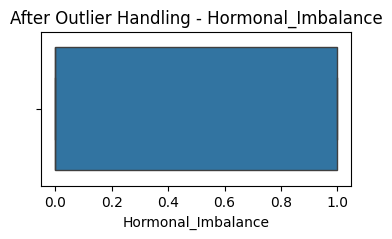

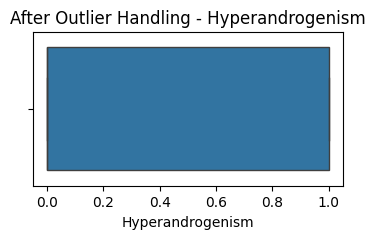

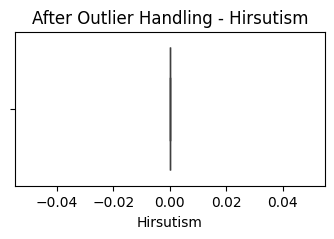

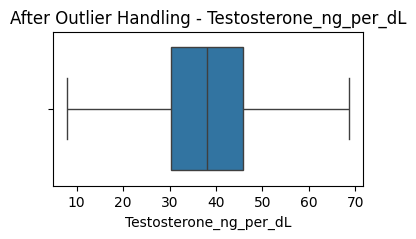

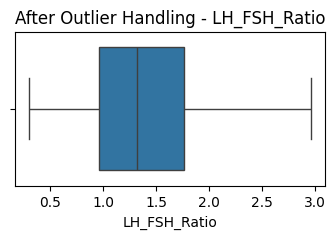

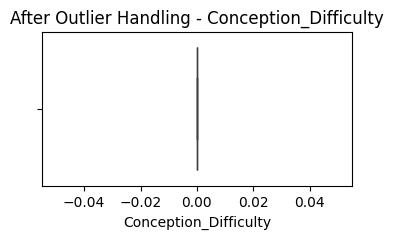

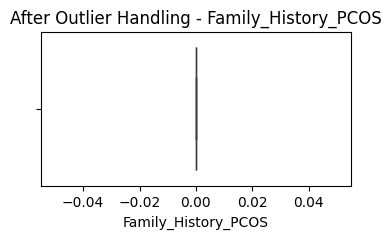

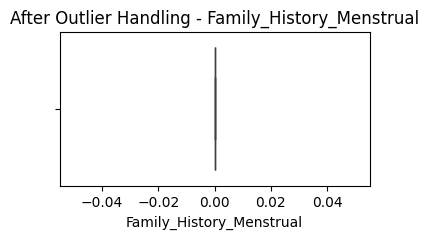

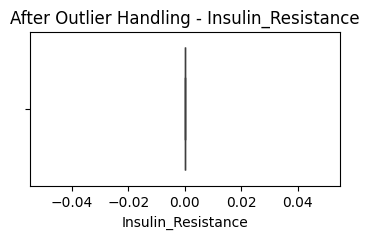

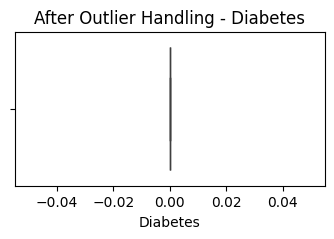

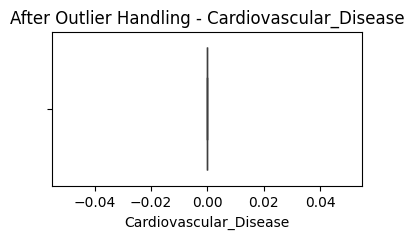

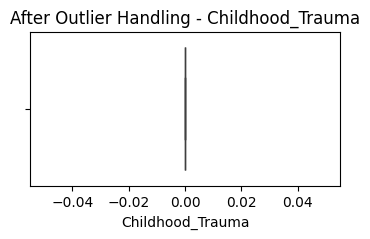

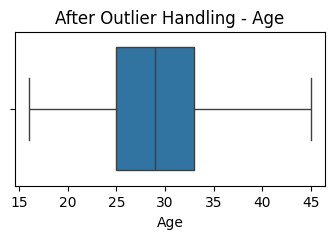

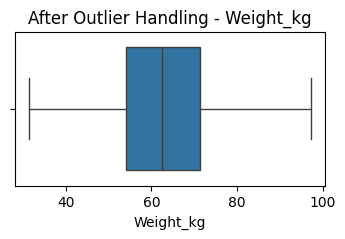

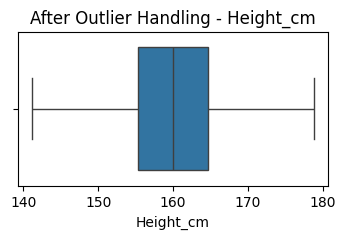

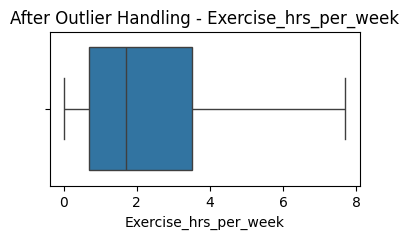

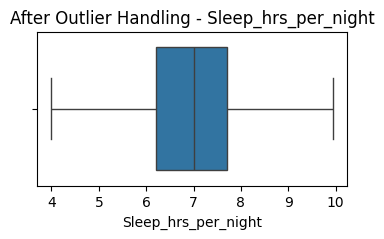

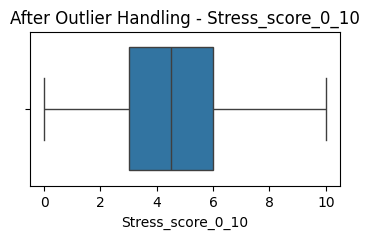

In [13]:
import pandas as pd
import numpy as np

def handle_outliers_iqr(df, numeric_cols, cap=True, verbose=True):
 
    df_clean = df.copy()
    outlier_summary = []

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # detect outliers
        mask = (df_clean[col] < lower) | (df_clean[col] > upper)
        n_outliers = mask.sum()

        if n_outliers > 0:
            outlier_summary.append((col, n_outliers, round(n_outliers/len(df_clean)*100,2)))

            if cap:
                # Winsorize: replace extreme values with caps
                df_clean.loc[df_clean[col] < lower, col] = lower
                df_clean.loc[df_clean[col] > upper, col] = upper
            else:
                # Drop rows containing outliers
                df_clean = df_clean.loc[~mask]

    if verbose:
        print("Outlier Handling Summary (IQR method):")
        if outlier_summary:
            for col, count, pct in outlier_summary:
                print(f"  - {col}: {count} outliers ({pct}%)")
        else:
            print("  No outliers detected.")

    return df_clean



# Identify numeric columns (float or int)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove the target from numeric features
if 'PCOS' in numeric_cols:
    numeric_cols.remove('PCOS')

# Handle outliers (caps them instead of removing)
df_clean = handle_outliers_iqr(df, numeric_cols, cap=True, verbose=True)

# Check result
print("\nShape before:", df.shape)
print("Shape after:", df_clean.shape)

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df_clean[col])
    plt.title(f"After Outlier Handling - {col}")
    plt.show()



In [14]:
exclude_cols = [
    'Hirsutism', 'Conception_Difficulty', 'Family_History_PCOS',
    'Family_History_Menstrual', 'Childhood_Trauma', 'Diabetes',
    'Cardiovascular_Disease', 'Insulin_Resistance'
]
numeric_cols_refined = [col for col in numeric_cols if col not in exclude_cols]

df_clean = handle_outliers_iqr(df, numeric_cols_refined, cap=True, verbose=True)
# After outlier handling
X = df_clean.drop('PCOS', axis=1)
y = df_clean['PCOS']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=30)


Outlier Handling Summary (IQR method):
  - Testosterone_ng_per_dL: 183 outliers (0.37%)
  - LH_FSH_Ratio: 208 outliers (0.42%)
  - Age: 262 outliers (0.52%)
  - Weight_kg: 309 outliers (0.62%)
  - Height_cm: 351 outliers (0.7%)
  - Exercise_hrs_per_week: 2320 outliers (4.64%)
  - Sleep_hrs_per_night: 173 outliers (0.35%)


In [15]:
numerical_cols = [
    'Age', 'Weight_kg', 'Height_cm', 'Testosterone_ng_per_dL',
    'LH_FSH_Ratio', 'Exercise_hrs_per_week', 'Sleep_hrs_per_night', 'Stress_score_0_10'
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [16]:
print(X_train.columns.tolist())


['Hormonal_Imbalance', 'Hyperandrogenism', 'Hirsutism', 'Testosterone_ng_per_dL', 'Menstrual_Cycle', 'LH_FSH_Ratio', 'Conception_Difficulty', 'Family_History_PCOS', 'Family_History_Menstrual', 'Insulin_Resistance', 'Diabetes', 'Cardiovascular_Disease', 'Mental_Health', 'Childhood_Trauma', 'Age', 'Weight_kg', 'Height_cm', 'Diet_Type', 'Veg_or_NonVeg', 'Exercise_hrs_per_week', 'Sleep_hrs_per_night', 'Stress_score_0_10', 'Smoking_Status']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# List your columns
numerical_cols = [
    'Age', 'Weight_kg', 'Height_cm', 'Testosterone_ng_per_dL',
    'LH_FSH_Ratio', 'Exercise_hrs_per_week', 'Sleep_hrs_per_night', 'Stress_score_0_10'
]
binary_cols = [
    'Menstrual_Cycle', 'Hormonal_Imbalance', 'Hyperandrogenism', 'Hirsutism',
    'Conception_Difficulty', 'Family_History_PCOS', 'Family_History_Menstrual',
    'Insulin_Resistance', 'Diabetes', 'Cardiovascular_Disease', 'Mental_Health',
    'Childhood_Trauma', 'Smoking_Status'
]
multi_cat_cols = ['Diet_Type', 'Veg_or_NonVeg']

# Build the ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('bin', OrdinalEncoder(), binary_cols),
    ('multi', OneHotEncoder(drop='first', handle_unknown='ignore'), multi_cat_cols)
])


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Example column lists
numerical_cols = [ 'Age', 'Weight_kg', 'Height_cm', 'Testosterone_ng_per_dL',
    'LH_FSH_Ratio', 'Exercise_hrs_per_week', 'Sleep_hrs_per_night', 'Stress_score_0_10'  ]  # your numerical columns


binary_cols = [ 'Menstrual_Cycle', 'Hormonal_Imbalance', 'Hyperandrogenism', 'Hirsutism',
    'Conception_Difficulty', 'Family_History_PCOS', 'Family_History_Menstrual',
    'Insulin_Resistance', 'Diabetes', 'Cardiovascular_Disease', 'Mental_Health',
    'Childhood_Trauma', 'Smoking_Status' ]     # your binary categorical columns

    
multi_cat_cols = [ 'Diet_Type', 'Veg_or_NonVeg' ]  # your multi-category columns

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('bin', Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
]), binary_cols),

    ('multi', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), multi_cat_cols)
])

In [19]:
import lightgbm as lgb
import catboost as cb
rf = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=30, n_jobs=-1)
xgb_clf = xgb.XGBClassifier(
    n_estimators=350, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=30, eval_metric='logloss'
)
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=350, learning_rate=0.05, num_leaves=31, random_state=30
)
cat_clf = cb.CatBoostClassifier(
    iterations=350, learning_rate=0.05, depth=6, verbose=0, random_state=30
)
svm_clf = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    probability=True,   
    random_state=30
)

meta_learner = LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced')


In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

# Make sure SVM is defined with probability=True
from sklearn.svm import SVC
svm_clf = SVC(probability=True, random_state=30)

# Define the stacking ensemble
stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb_clf),
        ('lgbm', lgbm_clf),
        ('cat', cat_clf),
        ('svm', svm_clf)
    ],
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=30),
    n_jobs=-1,
    passthrough=False
)

from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stack)  # your stacking ensemble
])


# Fit the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7520
           1       0.96      0.96      0.96      7480

    accuracy                           0.96     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       0.96      0.96      0.96     15000

[[7196  324]
 [ 264 7216]]


In [21]:
from sklearn.calibration import CalibratedClassifierCV
calibrated_pipeline = CalibratedClassifierCV(pipeline, method='isotonic', cv=3)
calibrated_pipeline.fit(X_train, y_train)

# Save this calibrated version
joblib.dump(calibrated_pipeline, "pcos_nonlinear_stack_calibrated.joblib")

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]


acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("\n📊 Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("SVM F1 Score:", f1_score(y_test, y_pred))
print("SVM ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")



📊 Model Performance:
Accuracy: 0.9608
F1 Score: 0.9609
ROC AUC: 0.9852
SVM Accuracy: 0.9608
SVM F1 Score: 0.9608521970705726
SVM ROC AUC: 0.9852434861759015

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7520
           1       0.96      0.96      0.96      7480

    accuracy                           0.96     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       0.96      0.96      0.96     15000

Confusion Matrix:


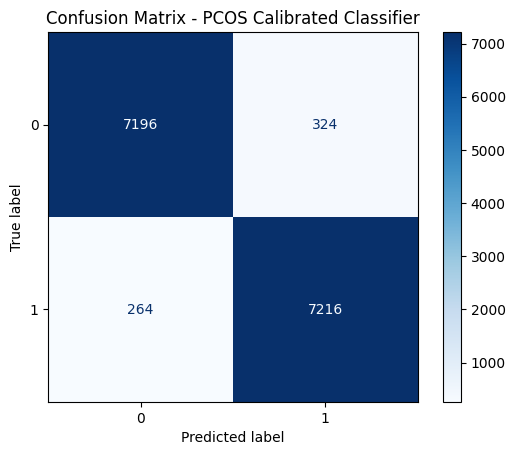

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - PCOS Calibrated Classifier")
plt.show()


In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "Random Forest": rf,
    "XGBoost": xgb_clf,
    "LightGBM": lgbm_clf,
    "CatBoost": cat_clf,
    "SVM (RBF)": svm_clf
}

results = []

for name, model in models.items():
    clf = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, f1, roc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "ROC AUC"])
print(results_df)


[LightGBM] [Info] Number of positive: 17452, number of negative: 17548
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1329
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498629 -> initscore=-0.005486
[LightGBM] [Info] Start training from score -0.005486
           Model  Accuracy  F1 Score   ROC AUC
0  Random Forest  0.958400  0.958632  0.984446
1        XGBoost  0.961133  0.961275  0.984963
2       LightGBM  0.960200  0.960382  0.984687
3       CatBoost  0.960533  0.960680  0.984901
4      SVM (RBF)  0.948067  0.948489  0.983206


In [24]:
joblib.dump(pipeline, "pcos_nonlinear_stack.joblib")
print("✅ Model saved as 'pcos_nonlinear_stack.joblib'")

✅ Model saved as 'pcos_nonlinear_stack.joblib'


In [25]:
def predict_patient_pcos(patient_data_dict):
    import joblib
    import pandas as pd

    try:
        pipeline = joblib.load("pcos_nonlinear_stack_calibrated.joblib")
    except FileNotFoundError:
        return {"error": "Model file not found. Train and save calibrated file first."}

    df_patient = pd.DataFrame([patient_data_dict])
    for col in df_patient.select_dtypes(include='object').columns:
        df_patient[col] = df_patient[col].astype(str).str.strip().str.title()

    try:
        prob = pipeline.predict_proba(df_patient)[:, 1][0]
        pred = int(prob >= 0.5)
    except Exception as e:
        return {"error": f"Prediction failed: {str(e)}"}

    # Widen "Moderate" range
    if prob >= 0.52:
        risk = "High"
    elif prob >= 0.3:
        risk = "Moderate"
    else:
        risk = "Low"

    return {
        "prediction": pred,
        "probability": round(prob * 100, 2),
        "risk": risk
    }


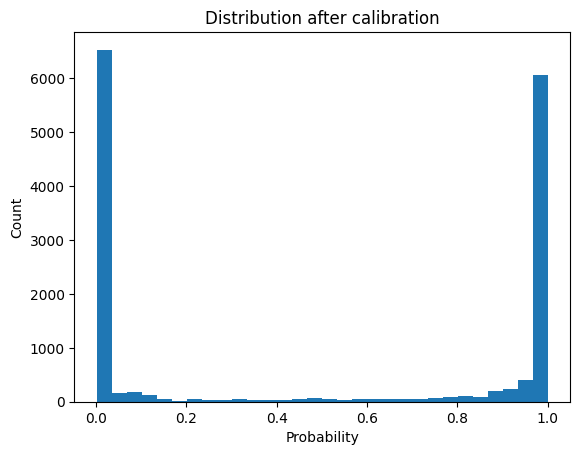

In [26]:
probs = calibrated_pipeline.predict_proba(X_test)[:, 1]
plt.hist(probs, bins=30)
plt.title('Distribution after calibration')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.show()


In [27]:
patient_high_example = {
"Age": 28,
    "Weight_kg": 67,
    "Height_cm": 160,
    "Testosterone_ng_per_dL": 200,
    "LH_FSH_Ratio": 1.3,
    "Exercise_hrs_per_week": 4,
    "Sleep_hrs_per_night": 7,
    "Stress_score_0_10": 6,
    "Menstrual_Cycle": "Irregular",
    "Hormonal_Imbalance": "Yes",
    "Hyperandrogenism": "Yes",
    "Hirsutism": "Mild",
    "Conception_Difficulty": "Yes",
    "Family_History_PCOS": "Yes",
    "Family_History_Menstrual": "Yes",
    "Insulin_Resistance": "Yes",
    "Diabetes": "yes",
    "Cardiovascular_Disease": "No",
    "Mental_Health": "Moderate",
    "Childhood_Trauma": "yes",
    "Smoking_Status": "yes",
    "Diet_Type": "Unhealthy",
    "Veg_or_NonVeg": "NonVeg"
}




result = predict_patient_pcos(patient_high_example )
print(result)


{'prediction': 1, 'probability': np.float64(53.81), 'risk': 'High'}


In [28]:
# This profile has both clinical and lifestyle risk factors.
moderate_risk_patient = {
    "Age": 32,
    "Weight_kg": 80,                    # Overweight BMI is a key risk factor
    "Height_cm": 165,
    "Testosterone_ng_per_dL": 68,
    "LH_FSH_Ratio": 2.4,
    "Exercise_hrs_per_week": 1.5,       # Low exercise
    "Sleep_hrs_per_night": 6,           # Suboptimal sleep
    "Stress_score_0_10": 7,             # High stress
    "Menstrual_Cycle": "Irregular",
    "Hormonal_Imbalance": "Yes",
    "Hyperandrogenism": "Yes",
    "Hirsutism": "Moderate",
    "Conception_Difficulty": "Yes",
    "Family_History_PCOS": "Yes",
    "Family_History_Menstrual": "Yes",
    "Insulin_Resistance": "Yes",
    "Diabetes": "No",
    "Cardiovascular_Disease": "No",
    "Mental_Health": "Moderate",
    "Childhood_Trauma": "No",
    "Smoking_Status": "No",
    "Diet_Type": "Unhealthy",
    "Veg_or_NonVeg": "Non-Veg"
}

# result = predict_patient_pcos(definitive_moderate_risk_patient)
# print(result)

result = predict_patient_pcos(moderate_risk_patient)
print(result)

{'prediction': 1, 'probability': np.float64(51.07), 'risk': 'Moderate'}


In [29]:
patient_low_example = {
    "Age": 23,
    "Weight_kg": 100,
    "Height_cm": 164,
    "Testosterone_ng_per_dL": 22,
    "LH_FSH_Ratio": 1.1,
    "Exercise_hrs_per_week": 5,
    "Sleep_hrs_per_night": 8,
    "Stress_score_0_10": 2,
    "Menstrual_Cycle": "IRRegular",
    "Hormonal_Imbalance": "No",
    "Hyperandrogenism": "No",
    "Hirsutism": "No",
    "Conception_Difficulty": "No",
    "Family_History_PCOS": "No",
    "Family_History_Menstrual": "No",
    "Insulin_Resistance": "No",
    "Diabetes": "No",
    "Cardiovascular_Disease": "No",
    "Mental_Health": "Good",
    "Childhood_Trauma": "No",
    "Smoking_Status": "No",
    "Diet_Type": "Vegetarian",
    "Veg_or_NonVeg": "Veg"
}

result = predict_patient_pcos(patient_low_example)
print(result)


{'prediction': 0, 'probability': np.float64(45.2), 'risk': 'Moderate'}



🔹 Training base model: RandomForest ...


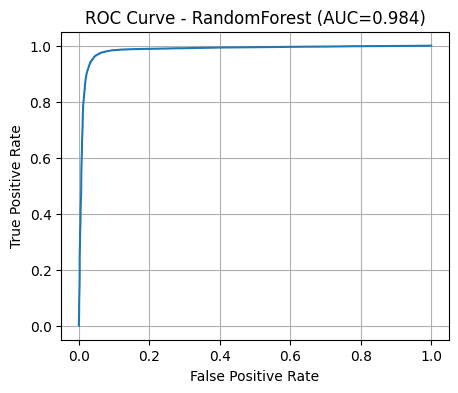

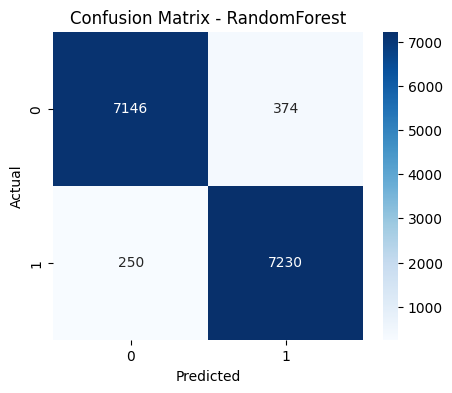


🔹 Training base model: XGBoost ...


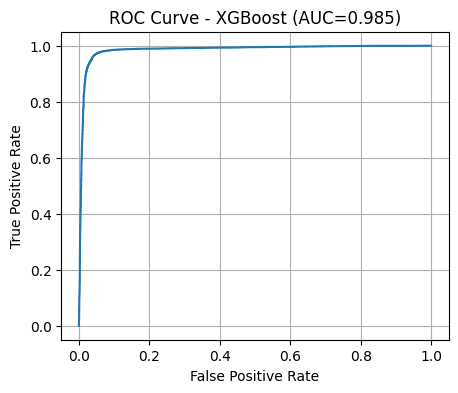

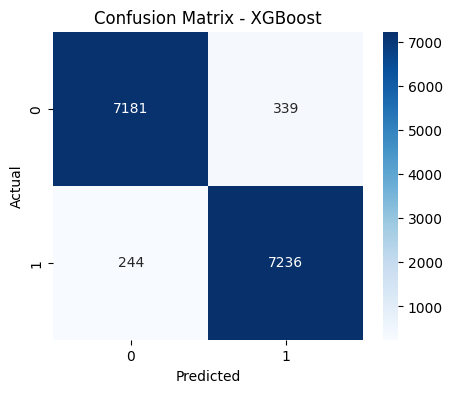


🔹 Training base model: LightGBM ...
[LightGBM] [Info] Number of positive: 17452, number of negative: 17548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1329
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498629 -> initscore=-0.005486
[LightGBM] [Info] Start training from score -0.005486


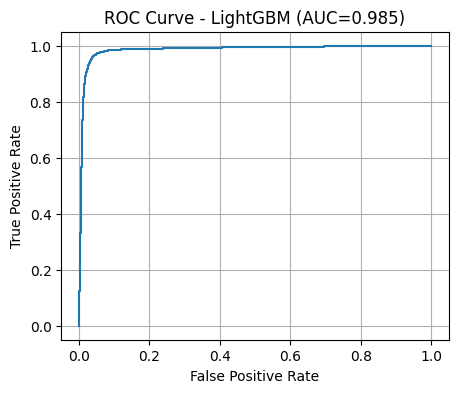

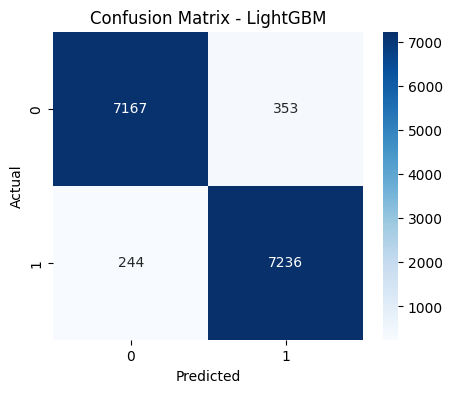


🔹 Training base model: CatBoost ...


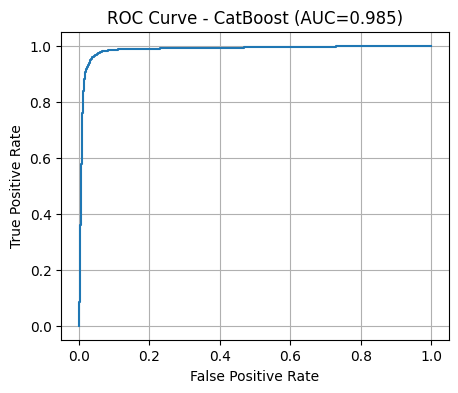

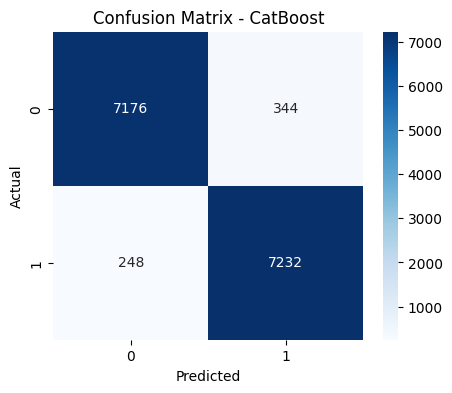


🔹 Training base model: SVM ...


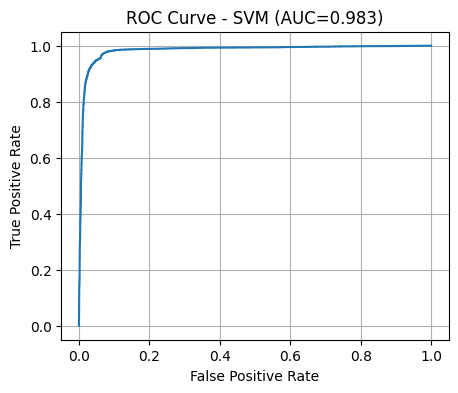

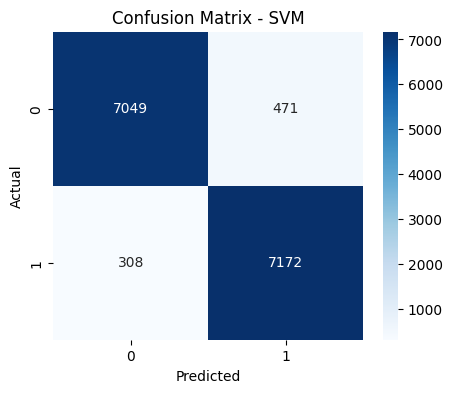

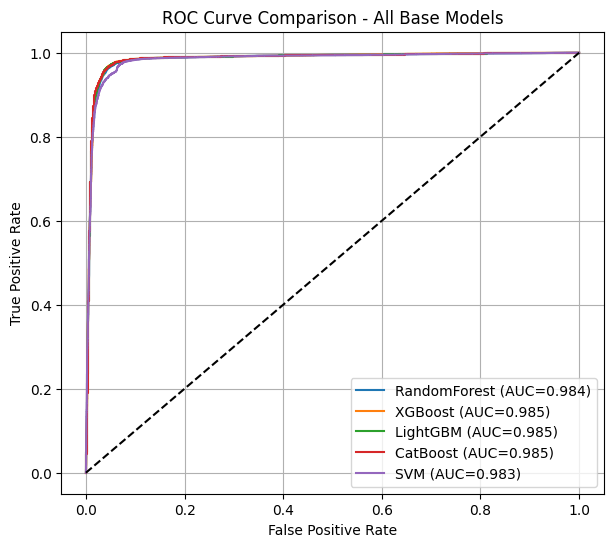

In [30]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# List of individual models inside your stacking ensemble
base_models = {
    "RandomForest": rf,
    "XGBoost": xgb_clf,
    "LightGBM": lgbm_clf,
    "CatBoost": cat_clf,
    "SVM": svm_clf
}

# Dictionary to store ROC values
fprs = {}
tprs = {}
aucs = {}

# ------------------------------------------------------------------------------
# ⭐ TRAIN EACH BASE MODEL SEPARATELY WITH SAME PREPROCESSING
# ------------------------------------------------------------------------------
for name, model in base_models.items():
    
    print(f"\n🔹 Training base model: {name} ...")
    
    base_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    base_pipe.fit(X_train, y_train)
    y_prob = base_pipe.predict_proba(X_test)[:, 1]
    y_pred = base_pipe.predict(X_test)

    # ---------------------------- ROC for each model ---------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    fprs[name] = fpr
    tprs[name] = tpr
    aucs[name] = roc_auc

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {name} (AUC={roc_auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()

    # ------------------------ Confusion Matrix ------------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ------------------------------------------------------------------------------
# ⭐ COMBINED ROC CURVE FOR ALL MODELS
# ------------------------------------------------------------------------------
plt.figure(figsize=(7,6))

for name in base_models.keys():
    plt.plot(fprs[name], tprs[name], label=f"{name} (AUC={aucs[name]:.3f})")

plt.plot([0,1], [0,1], 'k--')  
plt.title("ROC Curve Comparison - All Base Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


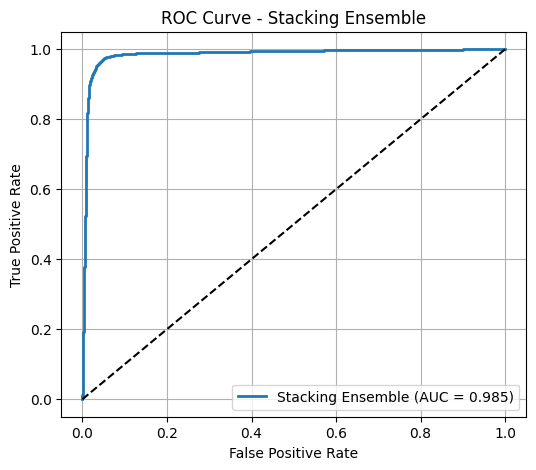


✅ Ensemble ROC-AUC Score: 0.9852


In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# Predict probabilities for ROC
# -------------------------------------------------
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# -------------------------------------------------
# Plot ROC Curve
# -------------------------------------------------
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Stacking Ensemble (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")
plt.legend()
plt.grid(True)
plt.show()

print(f"\n✅ Ensemble ROC-AUC Score: {roc_auc:.4f}")

Confusion Matrix:
 [[7196  324]
 [ 264 7216]]


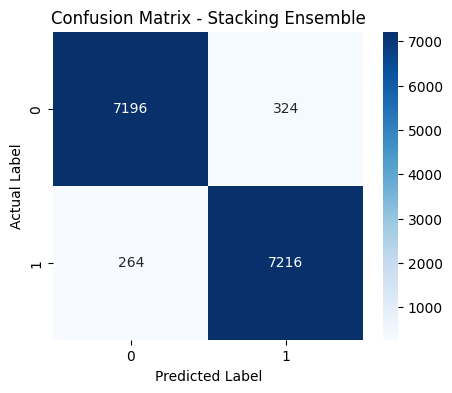

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions (if not already computed)
y_pred = pipeline.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()